# Household Behavior over the Life Cycle. Exam 2024.

## Setup

In [22]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Example: setup model instance, solve and simulate it.

In [23]:
from DynLaborModel import DynLaborModelClass
model = DynLaborModelClass()

model.solve()
model.simulate()

## Q2: Human capital depreciation shock
I have added the probability, $p_k=0,6$ and $\delta=0,2$ in DynLaborModel.py along with the necessary modifications. To implement this, I have included ``par.pk`` in the ``setup()`` function and updated the ``value_of_choice()`` function in the solution of the model. The depreciation rate is also included in the  ``setup()`` function as ``par.delta``.

I have also included a new uniform draw in the simulation of the model, stored in ``sim.delta_shock`` and used in the ``simulate()`` function to determine the transition of the human capital.


nesting check, max |diff| in mean hours: 8.224112765242708e-06


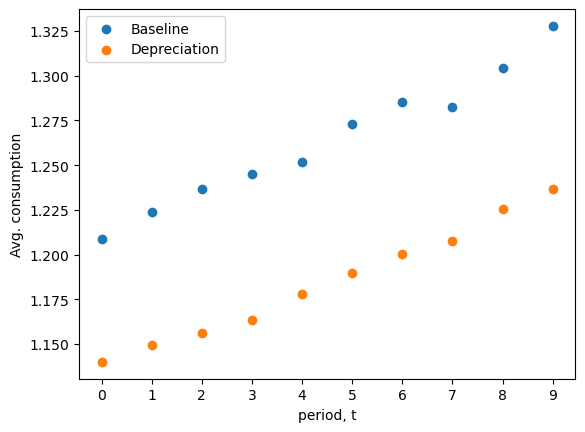

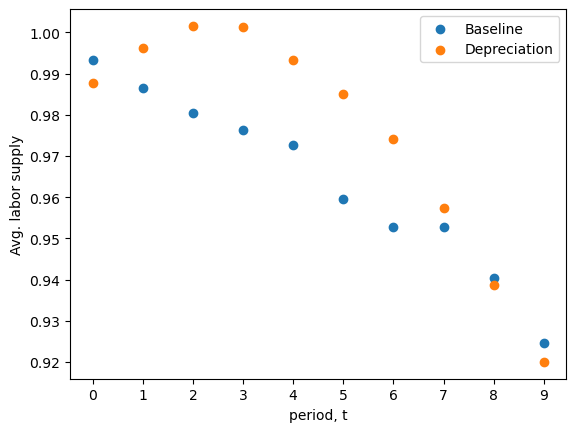

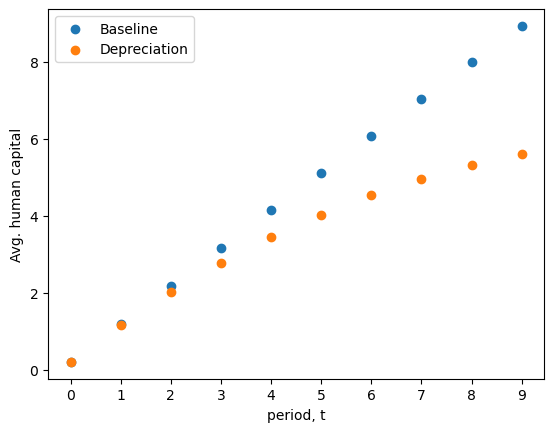

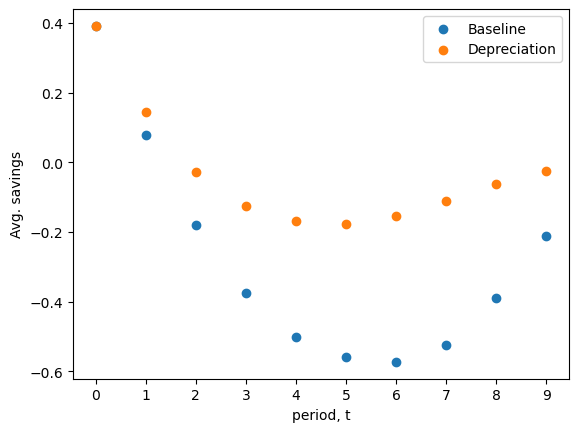

In [24]:
# baseline (depreciation switched off via delta = 0)
model_base = DynLaborModelClass(par={'delta':0.0, 'pk':0.6})
model_base.solve()
model_base.simulate()

# depreciation model
model_depr = DynLaborModelClass(par={'delta':0.2, 'pk':0.6})
model_depr.solve()
model_depr.simulate()

# nesting check (hint): pk = 0 should also reproduce the baseline
model_off = DynLaborModelClass(par={'delta':0.2, 'pk':0.0})
model_off.solve()
model_off.simulate()
print('nesting check, max |diff| in mean hours:',
      np.max(np.abs(np.mean(model_base.sim.h, axis=0) - np.mean(model_off.sim.h, axis=0))))

# plot comparison
labels = {'c':'consumption', 'h':'labor supply', 'k':'human capital', 'a':'savings'}
for var in ('c','h','k','a'):
    fig, ax = plt.subplots()
    ax.scatter(range(model_base.par.simT), np.mean(getattr(model_base.sim, var), axis=0), label='Baseline')
    ax.scatter(range(model_depr.par.simT), np.mean(getattr(model_depr.sim, var), axis=0), label='Depreciation')
    ax.legend()
    ax.set(xlabel='period, t', ylabel=f'Avg. {labels[var]}', xticks=range(model_base.par.simT))

## Q3: Tax rate on wealth
I modify the ``wealth_trans``and ``cons_last``functions. I add ``par.tau_a`` to the setup.
 

In [25]:
# baseline = Q2 model (depreciation on, tau_a = 0)
model_base = model_depr.copy()

# wealth-tax model: identical depreciation + shocks, just add the tax
model_tax = model_depr.copy()
model_tax.par.tau_a = 0.10
model_tax.solve()
model_tax.simulate()


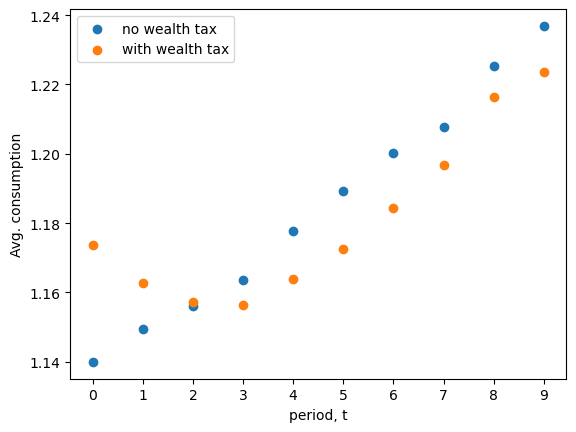

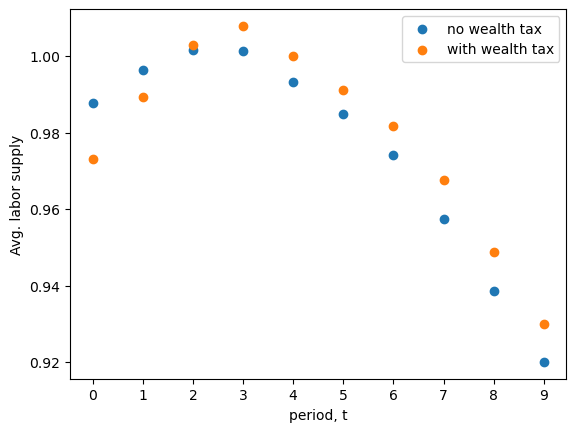

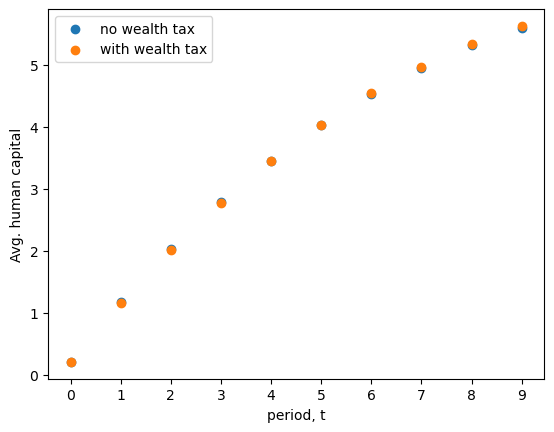

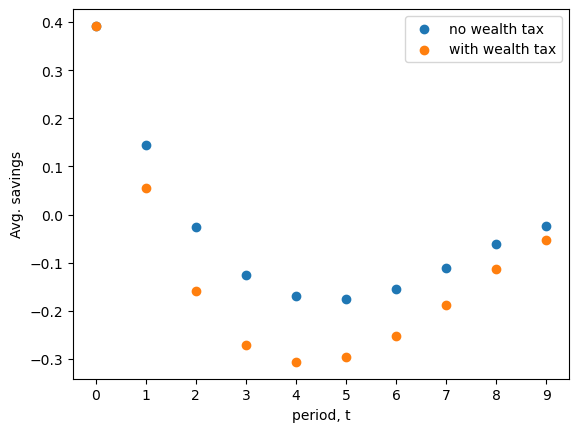

In [26]:
labels = {'c':'consumption', 'h':'labor supply', 'k':'human capital', 'a':'savings'}
for val in ('c','h','k','a'):
    base = np.nanmean(getattr(model_base.sim, val), axis=0)
    tax  = np.nanmean(getattr(model_tax.sim,  val), axis=0)
    fig, ax = plt.subplots()
    ax.scatter(range(len(base)), base, label='no wealth tax',   marker='o')
    ax.scatter(range(len(tax)),  tax,  label='with wealth tax', marker='o')
    ax.set(xlabel='period, t', ylabel=f'Avg. {labels[val]}', xticks=range(model_base.par.simT))
    ax.legend()

## Q5: Government budget and avg consumer welfare. 

The government budget is 1564.878
The welfare is -7.826


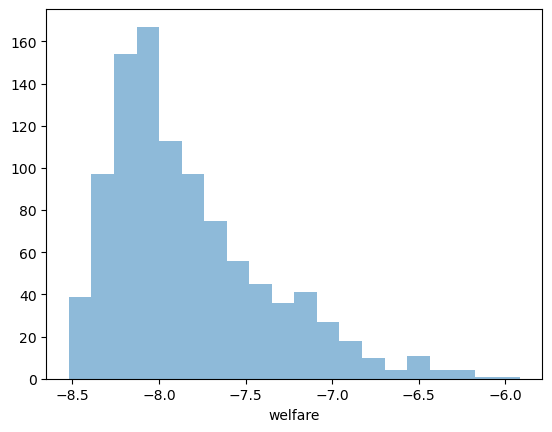

In [27]:
G_revenue = model.sim.budget.sum()
Welfare_indiv = np.sum(model.sim.util,axis=1)
Welfare = np.mean(Welfare_indiv)
print(f'The government budget is {G_revenue:2.3f}')
print(f'The welfare is {Welfare:2.3f}')

fig,ax = plt.subplots()
ax.hist(Welfare_indiv,alpha=0.5,bins=20);
ax.set(xlabel='welfare');

## Q6: Changes in $\tau$ and $\tau_a$.

In [28]:
# depreciation stays ON throughout; only the tax rates differ
common = {'delta':0.2, 'pk':0.6}
model_base = DynLaborModelClass(par={**common, 'tau':0.12, 'tau_a':0.10})  # baseline
model_tau  = DynLaborModelClass(par={**common, 'tau':0.10, 'tau_a':0.10})  # reform 1: labour-tax cut
model_taua = DynLaborModelClass(par={**common, 'tau':0.12, 'tau_a':0.05})  # reform 2: wealth-tax cut

for m in (model_base, model_tau, model_taua):
    m.solve(); m.simulate()

Baseline (τ=0.12, τ_a=0.10)            G = 1639.2
Reform 1: labour-tax cut (τ=0.10)      G = 1366.7
Reform 2: wealth-tax cut (τ_a=0.05)    G = 1608.6


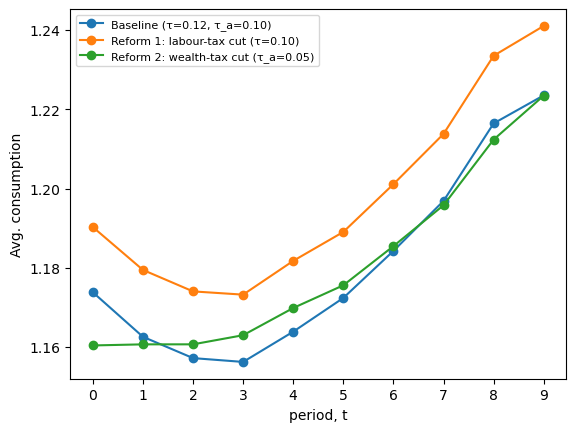

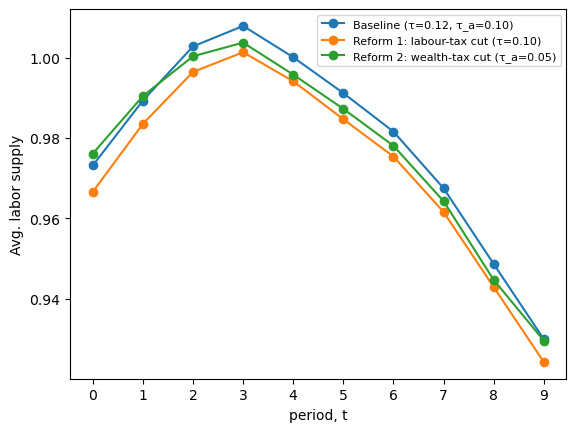

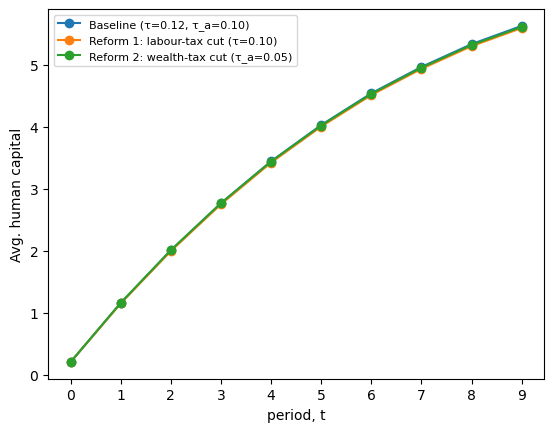

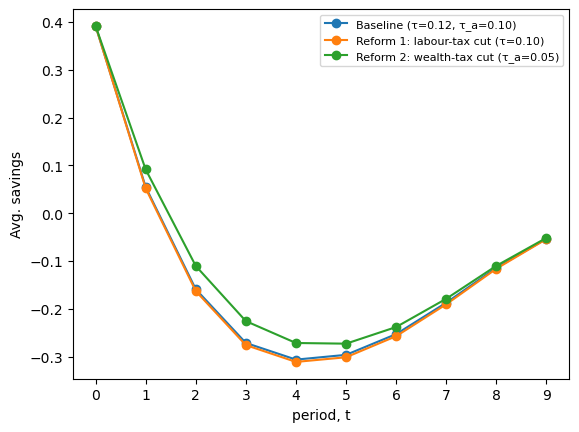

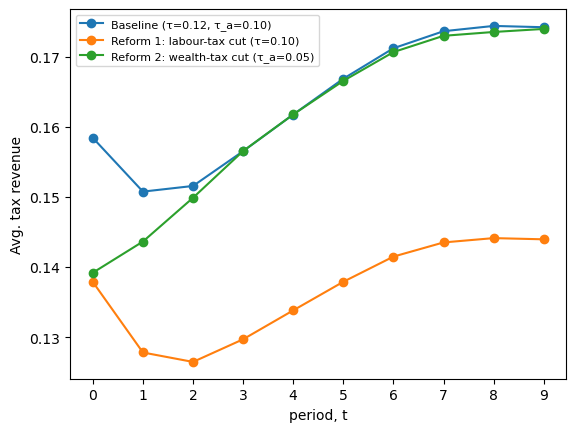

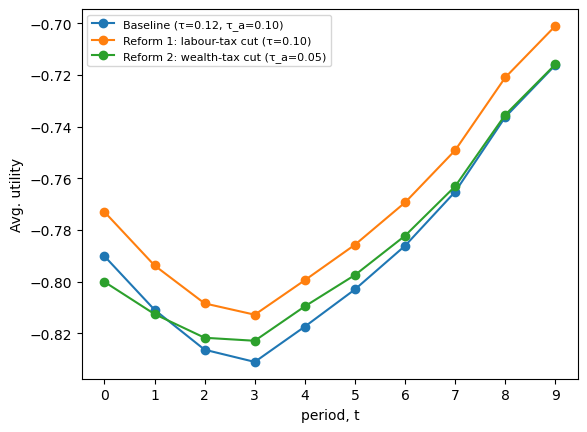

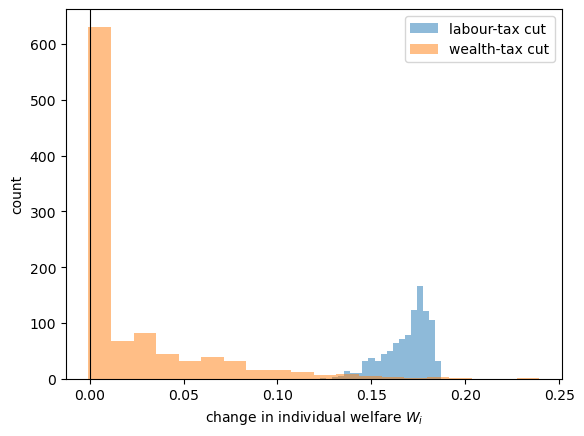

In [31]:
models = {'Baseline (τ=0.12, τ_a=0.10)':        model_base,
          'Reform 1: labour-tax cut (τ=0.10)':   model_tau,
          'Reform 2: wealth-tax cut (τ_a=0.05)':  model_taua}

# --- i–iv: life-cycle profiles (one figure per outcome, three lines each) ---
labels = {'c':'consumption', 'h':'labor supply', 'k':'human capital',
          'a':'savings', 'budget':'tax revenue', 'util':'utility'}
age = range(model_base.par.simT)
for var, name in labels.items():
    fig, ax = plt.subplots()
    for lab, m in models.items():                                  # one line per model
        ax.plot(age, np.nanmean(getattr(m.sim, var), axis=0), '-o', label=lab)
    ax.set(xlabel='period, t', ylabel=f'Avg. {name}', xticks=age)
    ax.legend(fontsize=8)

# --- iv (headline): total government budget G for each model ---
for lab, m in models.items():
    print(f'{lab:38s} G = {m.sim.budget.sum():.1f}')

# --- v: distribution of the CHANGE in individual welfare from each reform ---
W_base    = np.sum(model_base.sim.util, axis=1)               # baseline welfare per person
diff_tau  = np.sum(model_tau.sim.util,  axis=1) - W_base      # gain from labour-tax cut
diff_taua = np.sum(model_taua.sim.util, axis=1) - W_base      # gain from wealth-tax cut

fig, ax = plt.subplots()
ax.hist(diff_tau,  alpha=0.5, bins=20, label='labour-tax cut')
ax.hist(diff_taua, alpha=0.5, bins=20, label='wealth-tax cut')
ax.axvline(0, color='k', linewidth=0.8)                       # right of 0 = better off
ax.set(xlabel='change in individual welfare $W_i$', ylabel='count')
ax.legend()

## Q7: Which level of labor-tax income rate generate the same amount of government budget of 1900


In [32]:
from scipy.optimize import brentq

def budget_gap(tau, tau_a, target=1900.0):
    # solve+simulate the model at these tax rates, return how far G is from the target
    m = DynLaborModelClass(par={'delta':0.2, 'pk':0.6, 'tau':tau, 'tau_a':tau_a})
    m.solve(); m.simulate()
    return m.sim.budget.sum() - target

# 1) labour tax that raises 1900, with tau_a fixed at 0.10
tau_G = brentq(lambda tau: budget_gap(tau, 0.10), 0.10, 0.20)

# 2) wealth tax that raises 1900, with tau fixed at 0.12
tau_a_G = brentq(lambda tau_a: budget_gap(0.12, tau_a), 0.40, 0.80)

print(f'tau^G    = {tau_G:.4f}   (tax system: tau^G,   tau_a = 0.10)')
print(f'tau_a^G  = {tau_a_G:.4f}  (tax system: tau = 0.12, tau_a^G)')

tau^G    = 0.1389   (tax system: tau^G,   tau_a = 0.10)
tau_a^G  = 0.7903  (tax system: tau = 0.12, tau_a^G)


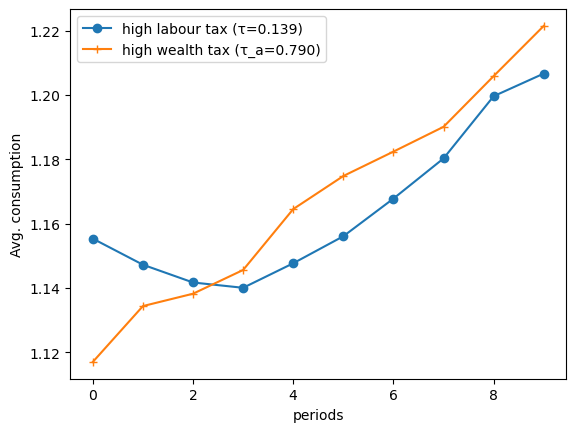

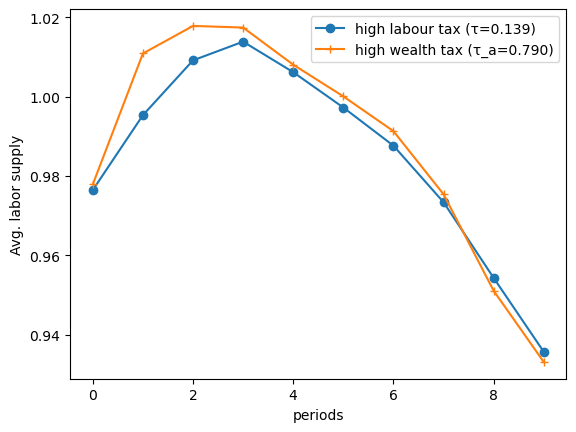

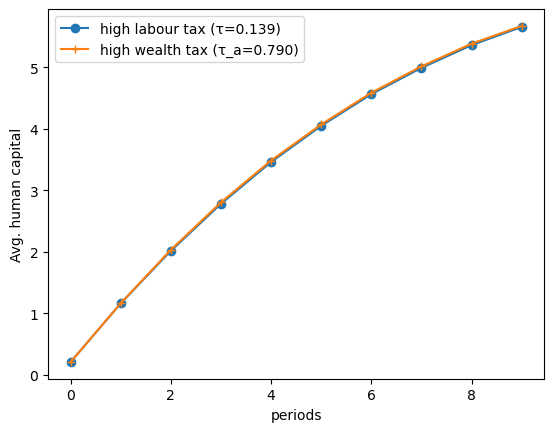

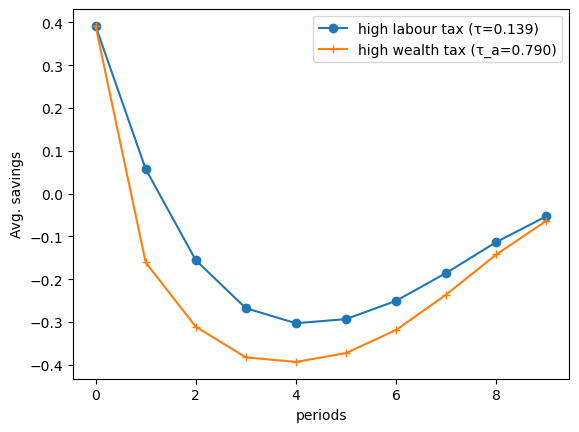

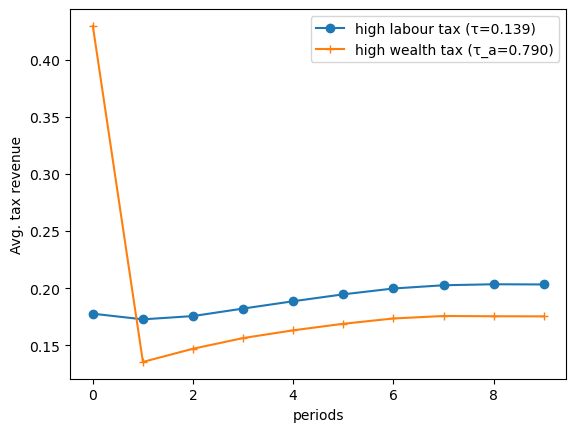

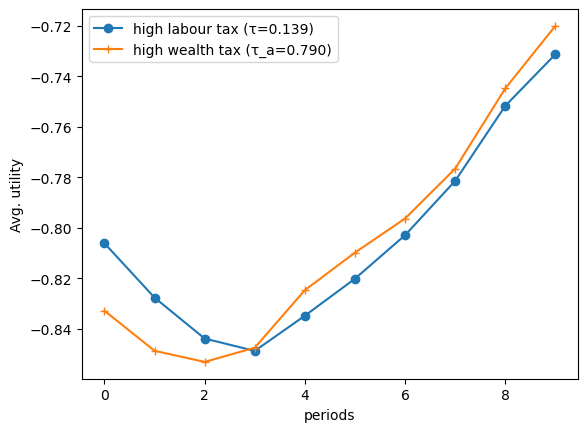

In [35]:
# the two tax systems that both raise 1900
model_tauG  = DynLaborModelClass(par={'delta':0.2,'pk':0.6, 'tau':tau_G,  'tau_a':0.10})    # (tau^G, tau_a)
model_tauaG = DynLaborModelClass(par={'delta':0.2,'pk':0.6, 'tau':0.12,   'tau_a':tau_a_G}) # (tau, tau_a^G)
model_tauG.solve();  model_tauG.simulate()
model_tauaG.solve(); model_tauaG.simulate()

# plot the five life-cycle profiles for the two regimes
labels = {'c':'consumption', 'h':'labor supply', 'k':'human capital',
          'a':'savings', 'budget':'tax revenue', 'util':'utility'}

for val in ('c','h','k','a','budget','util'):
    fig, ax = plt.subplots()
    ax.plot(np.mean(getattr(model_tauG.sim,  val), axis=0), label=f'high labour tax (τ={tau_G:.3f})',     marker='o')
    ax.plot(np.mean(getattr(model_tauaG.sim, val), axis=0), label=f'high wealth tax (τ_a={tau_a_G:.3f})', marker='+')
    ax.set(ylabel=f'Avg. {labels[val]}', xlabel='periods')
    ax.legend()

## Q9: Use SMM to find the beta estimate that fits the target of 35/39

In [36]:
from scipy.optimize import minimize_scalar

target_h = 35/37   # 0.946: avg weekly hours of 35 out of a 37-hour full week

def obj(beta):
    # solve+simulate at this beta, return squared gap between model avg hours and the data target
    m = DynLaborModelClass(par={'delta':0.2,'pk':0.6,'tau':0.12,'tau_a':0.10,'beta':beta})
    m.solve(); m.simulate()
    return (np.mean(m.sim.h) - target_h)**2

res = minimize_scalar(obj, bounds=(0.5, 1.5), method='bounded')   # search beta in (0.5,1.5)
beta_hat = res.x

# report estimate and model fit
m_hat = DynLaborModelClass(par={'delta':0.2,'pk':0.6,'tau':0.12,'tau_a':0.10,'beta':beta_hat})
m_hat.solve(); m_hat.simulate()
print(f'estimated beta = {beta_hat:.4f}')
print(f'target hours   = {target_h:.4f}')
print(f'model hours    = {np.mean(m_hat.sim.h):.4f}   (the model fit)')

estimated beta = 1.1893
target hours   = 0.9459
model hours    = 0.9459   (the model fit)


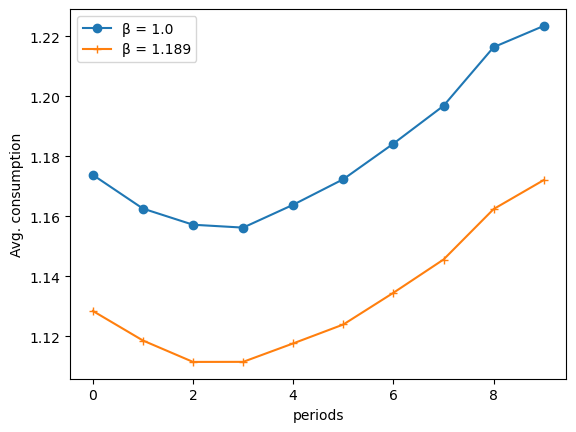

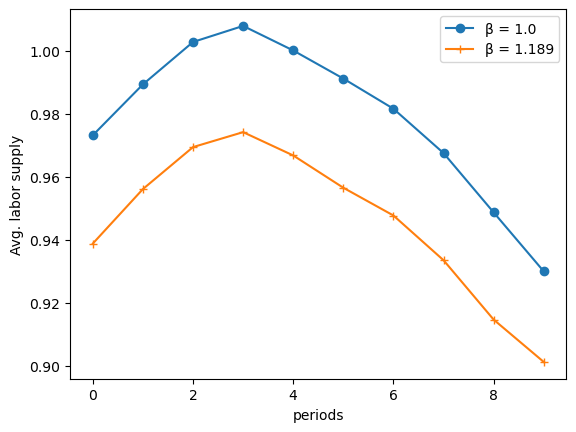

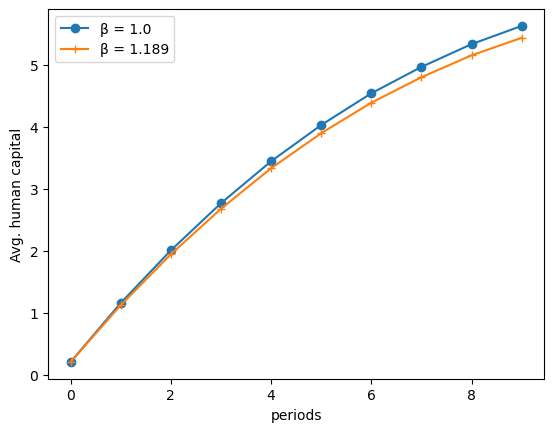

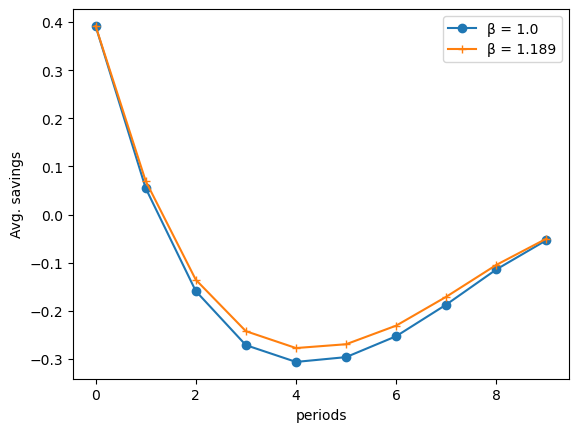

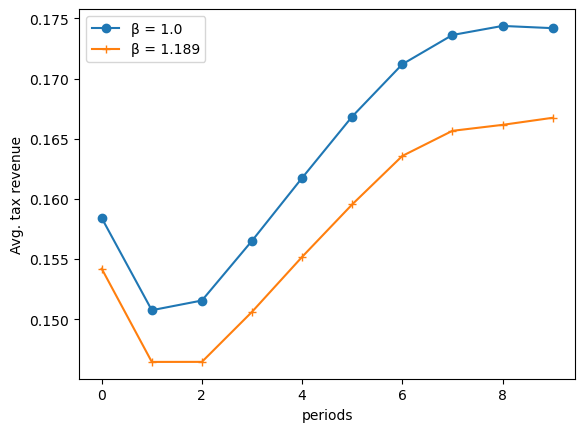

In [38]:
# baseline beta vs estimated beta — Q3 model with baseline taxes
model_b1   = DynLaborModelClass(par={'delta':0.2,'pk':0.6,'tau':0.12,'tau_a':0.10,'beta':1.0})
model_bhat = DynLaborModelClass(par={'delta':0.2,'pk':0.6,'tau':0.12,'tau_a':0.10,'beta':beta_hat})
model_b1.solve();   model_b1.simulate()
model_bhat.solve(); model_bhat.simulate()

labels = {'c':'consumption', 'h':'labor supply', 'k':'human capital',
          'a':'savings', 'budget':'tax revenue', 'util':'utility'}

for val in ('c','h','k','a','budget'):
    fig, ax = plt.subplots()
    ax.plot(np.mean(getattr(model_b1.sim,   val), axis=0), label='β = 1.0',             marker='o')
    ax.plot(np.mean(getattr(model_bhat.sim, val), axis=0), label=f'β = {beta_hat:.3f}', marker='+')
    ax.set(ylabel=f'Avg. {labels[val]}', xlabel='periods')
    ax.legend()

## Q11: Disability added to the model.
To implement the model, I modify both the solution and simulation module.

In the solution, I add a loop over `disabled` taking values 0 and 1. The functions I update are `wage_func_before_tax()`, which cuts the wage when `disabled` is 1, and `wealth_trans()` and `cons_last()`, which add the `disability_benefit` when disabled. `value_of_choice()` now takes the expectation over both the depreciation shock and the disability transition.

In the simulation, everyone starts healthy. I draw $N\cdot T$ uniform draws to determine each period whether the individual is disabled next period (probability `pd` if healthy, $2\cdot$`pd` if disabled), and I subtract the `disability_benefit` when calculating the government budget.

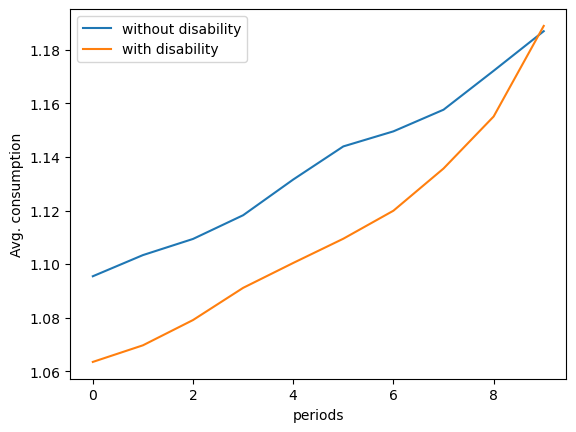

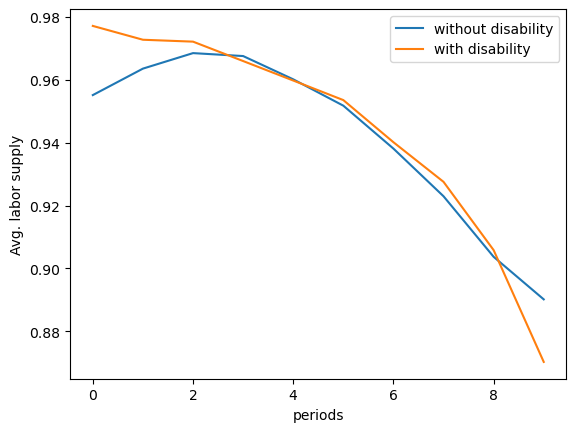

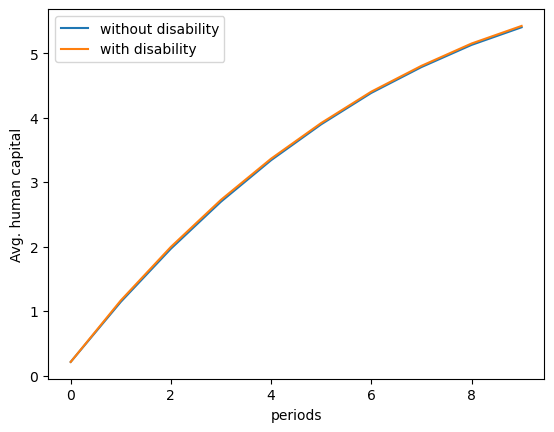

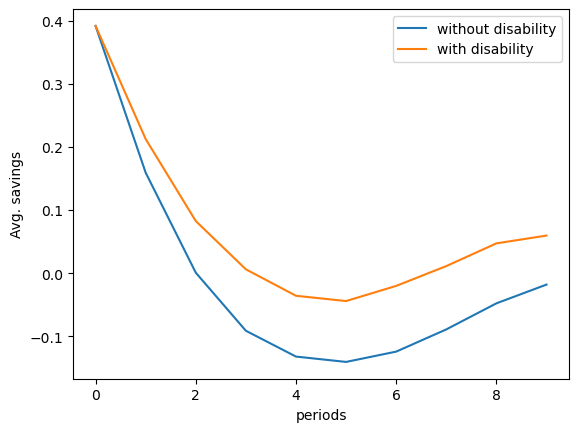

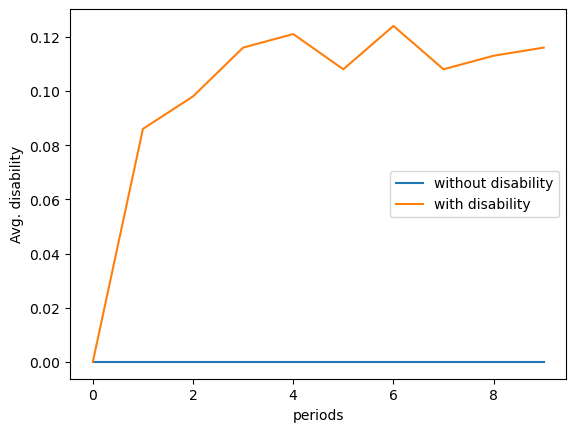

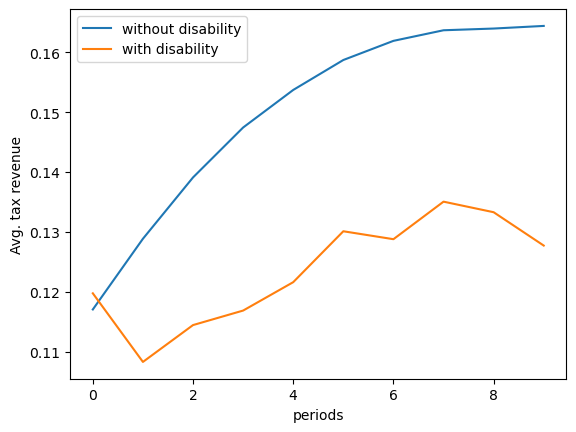

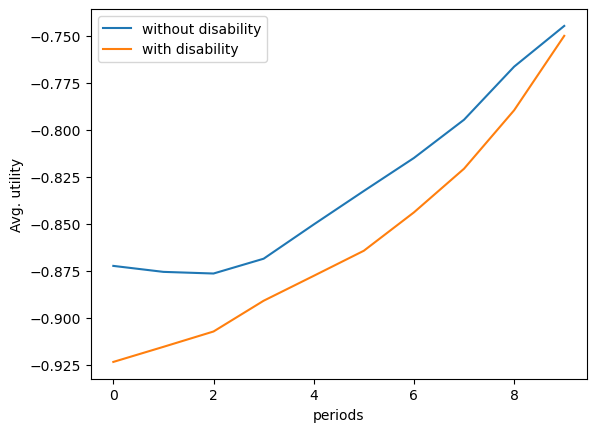

In [44]:
from DynLaborModel import DynLaborModelClass

model       = DynLaborModelClass(par={'beta':beta_hat, 'pd':0.0})   # without disability
model_final = DynLaborModelClass(par={'beta':beta_hat, 'pd':0.1})   # with disability
model.solve();        model.simulate()
model_final.solve();  model_final.simulate()

labels = {'c':'consumption', 'h':'labor supply', 'k':'human capital',
          'a':'savings', 'budget':'tax revenue', 'util':'utility', 'd':'disability'}

for val in ('c','h','k','a','d','budget','util'):
    var1 = np.nanmean(getattr(model.sim,      val), axis=0)
    var2 = np.nanmean(getattr(model_final.sim,val), axis=0)
    fig, ax = plt.subplots()
    ax.plot(var1, label='without disability')
    ax.plot(var2, label='with disability')
    ax.set(ylabel=f'Avg. {labels[val]}', xlabel='periods')
    ax.legend()